**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.


# 09. Statistical Analysis in Numerics
This notebook covers statistical methods and hypothesis testing.

## What You'll Learn

- Descriptive statistics
- Correlation analysis (Pearson, Spearman, Kendall)
- Hypothesis testing (t-test, Mann-Whitney, Kolmogorov-Smirnov)
- Bootstrap resampling
- Outlier detection (Multiple Grubbs-Beck)
- Data transformations (Box-Cox, Yeo-Johnson)
- Histogram and kernel density estimation

## Real-World Applications

Statistical analysis for data exploration, quality control, and inference.

## Set Up


In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Numerics DLL (auto-discovered from NuGet; see notebook 00 for details)
from helper_functions import resolve_numerics_dll
clr.AddReference(str(resolve_numerics_dll()))

from Numerics.Data.Statistics import Statistics, Correlation, HypothesisTests, GoodnessOfFit, MultipleGrubbsBeckTest, BoxCox, YeoJohnson
from Numerics.Distributions import Normal, LogNormal, Uniform, GammaDistribution, Exponential, BootstrapAnalysis, ParameterEstimationMethod
from Numerics.MachineLearning import JenksNaturalBreaks
from helper_functions import convert_to_dotnet_array
from System import Array

print("✓ Setup complete")

✓ Setup complete


## Descriptive Statistics

Let's analyze streamflow data to find some basic statistics. First we define the mathematical formulas underlying these methods in Numerics.

### Sample Mean 
The arithmetic mean of $n$ observations:
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

### Sample Variance (Bessel's Correction)
The unbiased estimator of the population variance divides by $n-1$ rather than $n$. This is known as Bessel's correction, and it compensates for the bias that arises when using the sample mean in place of the true population mean. The `Variance` method returns this estimator:
$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$
The source code implements this using a numerically stable one-pass recurrence rather than the naive two-pass formula shown above [[1]](#1). The two approaches are mathematically equivalent, but the one-pass algorithm avoids catastrophic cancellation when the mean is large relative to the variance.

### Skewness (Fisher's Adjusted)
The `Skewness` method computes the bias-corrected Fisher skewness (type 2), which adjusts the raw sample skewness for sample size [[2]](#2):
$$
G_1 = \frac{\sqrt{n(n-1)}}{n-2} \cdot g_1
$$
where $g_1 = m_3 / m_2^{3/2}$ is the sample skewness computed from the central moments $m_k = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^k$.

Interpretation:
- $G_1 > 0$: right-skewed (long right tail)
- $G_1 < 0$: left-skewed (long left tail)
- $|G_1| < 0.5$: approximately symmetric

### Excess Kurtosis (Fisher's Adjusted) 
`Kurtosis` method computes bias-corrected excess kurtosis (type 2) [[2]](#2). Excess kurtosis subtracts 3 from Pearson's kurtosis so that the normal distribution has a value of zero:
$$
G_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \cdot \frac{\sum(x_i - \bar{x})^4}{s^4} - \frac{3(n-1)^2}{(n-2)(n-3)}
$$
where $s^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ is the sample variance.

Interpretation:
- $G_2 > 0$: leptokurtic (heavier tails than normal)
- $G_2 < 0$: platykurtic (lighter tails than normal)
- $G_2 \approx 0$: mesokurtic (similar to normal distribution)

Mean, standard deviation, skewness, and kurtosis can easily be found all at once using the `ProductMoments`  method.

### Percentiles and Quantiles
The library computes percentiles using Type 7 linear interpolation, which is the default method in R and Excel. For a given probability $p \in [0, 1]$:
$$
Q(p) = x_{\lfloor h \rfloor} + (h - \lfloor h \rfloor)(x_{\lceil h \rceil} - x_{\lfloor h \rfloor})
$$
where $h = (n-1)p$ and $x_i$ are the sorted data values (0-indexed). When $h$ falls exactly on an integer, the result is the corresponding order statistic; otherwise, it linearly interpolates between the two adjacent order statistics.


Summary statistics


,Statistic,Value
0,Mean,1.397387e+07
1,Std Dev,4.195469e+07
2,Variance,1.760196e+15
3,Minimum,7.526316e+03
4,Maximum,5.909717e+08
5,Skewness,8.697790e+00
6,Kurtosis,1.038059e+02
7,5th %ile,1.270829e+05
8,25th %ile,8.245169e+05
9,75th %ile,8.827698e+06


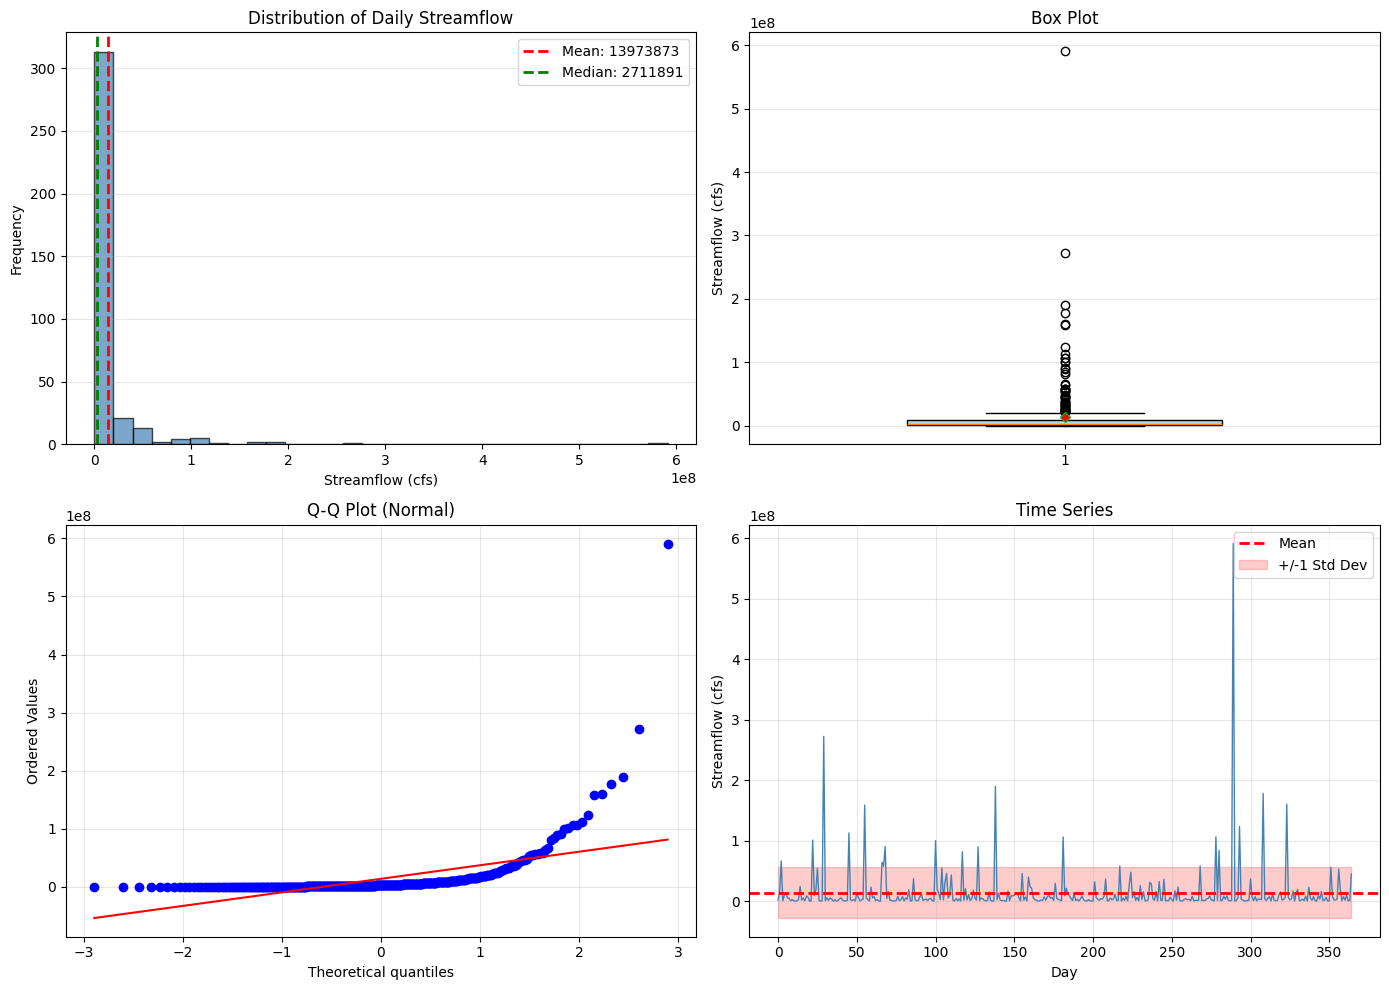

In [2]:
# Generate sample streamflow data (cubic feet per second)
streamflow = np.array(list(LogNormal(6.5, 0.8).GenerateRandomValues(365, 42)))
streamflow_net = convert_to_dotnet_array(streamflow)

# Pull basic statistics
summary_df = pd.DataFrame({'Statistic':['Mean','Std Dev','Variance','Minimum','Maximum','Skewness','Kurtosis','5th %ile','25th %ile','75th %ile','95th %ile'],
                           'Value': [Statistics.Mean(streamflow_net),Statistics.StandardDeviation(streamflow_net),Statistics.Variance(streamflow_net),
                            Statistics.Minimum(streamflow_net),Statistics.Maximum(streamflow_net),Statistics.Skewness(streamflow_net),
                            Statistics.Kurtosis(streamflow_net),Statistics.Percentile(streamflow_net,0.05),Statistics.Percentile(streamflow_net,0.25),
                            Statistics.Percentile(streamflow_net,0.75),Statistics.Percentile(streamflow_net,0.95)]})
print('Summary statistics')
display(summary_df)

# Plot frequency
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(streamflow, bins=30, alpha=0.7, color='steelblue', edgecolor='black')

# Find mean and median
axes[0, 0].axvline(np.mean(streamflow), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(streamflow):.0f}')
axes[0, 0].axvline(np.median(streamflow), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(streamflow):.0f}')
axes[0, 0].set_xlabel('Streamflow (cfs)'); axes[0, 0].set_ylabel('Frequency'); axes[0, 0].set_title('Distribution of Daily Streamflow'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot boxplots
bp = axes[0, 1].boxplot([streamflow], vert=True, patch_artist=True, widths=0.5, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=5))
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Streamflow (cfs)'); axes[0, 1].set_title('Box Plot'); axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot QQ-plot
stats.probplot(streamflow, dist='norm', plot=axes[1, 0]); axes[1, 0].set_title('Q-Q Plot (Normal)'); axes[1, 0].grid(True, alpha=0.3)

# Plot timeseries data
axes[1, 1].plot(range(len(streamflow)), streamflow, linewidth=1, color='steelblue')

# Plot mean
axes[1, 1].axhline(np.mean(streamflow), color='red', linestyle='--', linewidth=2, label='Mean')

# Plot confidence interval
axes[1, 1].fill_between(range(len(streamflow)), np.mean(streamflow)-np.std(streamflow), np.mean(streamflow)+np.std(streamflow), alpha=0.2, color='red', label='+/-1 Std Dev')
axes[1, 1].set_xlabel('Day'); axes[1, 1].set_ylabel('Streamflow (cfs)'); axes[1, 1].set_title('Time Series'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Correlation Analysis
For correlation coefficients, use the `Correlation` class. Three measures are provided, each capturing a different aspect of association between two variables.

### 1. Pearson correlation
Measures the strength and direction of the linear relationship between two variables[[3]](#3):

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

### 2. Spearman rank correlation 
This is the Pearson correlation applied to the ranks of the data rather than the data values themselves. This makes it a nonparametric measure of monotonic association:

$$
\rho_s = r(\text{rank}(x), \text{rank}(y))
$$

### 3. Kendall's $\tau_b$ [[4]](#4) 
Measures the strength of ordinal association, adjusted for ties. The library implements $\tau_b$:

$$
\tau_b = \frac{n_c - n_d}{\sqrt{n_1 \cdot n_2}}
$$

where $n_c$ is the number of concordant pairs, $n_d$ is the number of discordant pairs, $n_1$ is the number of pairs not tied in $x$, and $n_2$ is the number of pairs not tied in $y$.

### When to Use Which Correlation:

| Correlation | Measures | Robust to Outliers | Handles Nonlinear |
|------------|----------|-------------------|------------------|
| Pearson | Linear association | No | No |
| Spearman | Monotonic association | Yes | Yes (monotonic) |
| Kendall's $\tau_b$ | Concordance | Yes | Yes (monotonic) |

Rules of thumb:
- Pearson: use for normally distributed data with linear relationships.
- Spearman: use when data has outliers or the relationship is monotonic but not linear.
- Kendall's $\tau_b$: more robust than Spearman for small samples and has better statistical properties. Preferred when there are many tied values.

The `Correlation` class also provides matrix versions (`Pearson(double[,])` and `Spearman(double[,])`) that compute the full $p \times p$ correlation matrix for multivariate data.



Correlation Analysis:
Pearson correlation:   1.0000  (linear relationship)
Spearman correlation:  1.0000  (monotonic relationship)
Kendall's tau:         1.0000  (rank correlation)


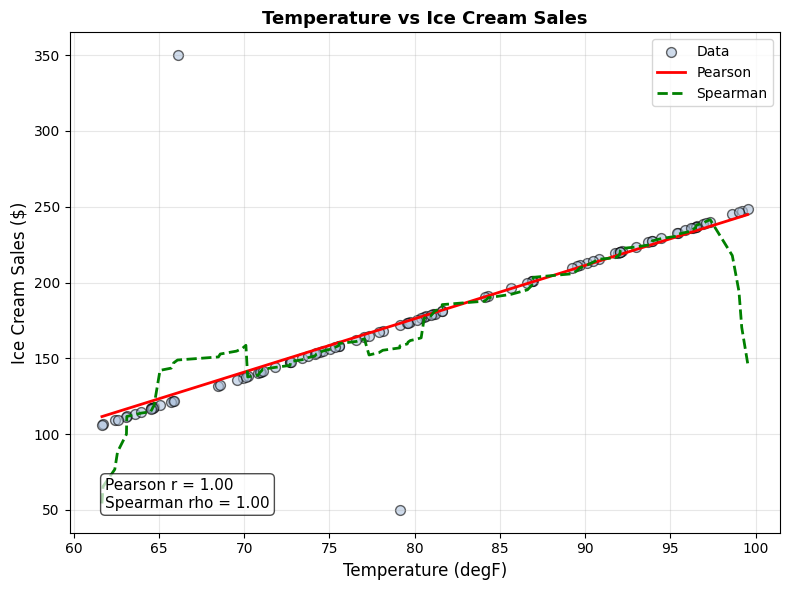

In [3]:
# Generate correlated data: temperature vs ice cream sales
n = 100
temperature = Uniform(60,100).GenerateRandomValues(n,321)
temp_py = np.array(temperature)
noise = Uniform(0, 50).GenerateRandomValues(n,321)
ice_cream_sales = 2.5 * temp_py - 50 + np.array(noise)

# Convert to .NET for Numerics
sales_net = convert_to_dotnet_array(ice_cream_sales)

# Add some outliers
ice_cream_sales[5] = 50
ice_cream_sales[50] = 350

# Pearson correlation (linear)
pearson_corr = Correlation.Pearson(temperature, sales_net)

# Spearman correlation (rank-based)
spearman_corr = Correlation.Spearman(temperature, sales_net)

# Kendall Tau correlation (ordinal)
kendall_corr = Correlation.KendallsTau(temperature, sales_net)

print("\nCorrelation Analysis:")
print(f"Pearson correlation:   {pearson_corr:.4f}  (linear relationship)")
print(f"Spearman correlation:  {spearman_corr:.4f}  (monotonic relationship)")
print(f"Kendall's tau:         {kendall_corr:.4f}  (rank correlation)")

# Visualize correlations
plt.figure(figsize=(8, 6))

plt.text(0.05, 0.05,
         f"Pearson r = {pearson_corr:.2f}\n"
         f"Spearman rho = {spearman_corr:.2f}",
         transform=plt.gca().transAxes,
         fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))


# Scatter
plt.scatter(temp_py, ice_cream_sales, alpha=0.6, s=50,
            color='lightsteelblue', edgecolor='black', label='Data')

# 1) Pearson: linear fit
z = np.polyfit(temp_py, ice_cream_sales, 1)
p = np.poly1d(z)
x_line = np.linspace(temp_py.min(), temp_py.max(), 200)
plt.plot(x_line, p(x_line), 'r-', linewidth=2,
         label=f'Pearson')

# 2) Spearman: monotonic smooth curve (fit in rank space, plot in x-space)
order = np.argsort(temp_py)     # Sort by temperature
temp_sorted = temp_py[order]
sales_sorted = ice_cream_sales[order]

# Smooth with a lowess/rolling mean style approximation (no extra libs)
window = max(5, len(temp_sorted)//10)
smoothed = np.convolve(sales_sorted, np.ones(window)/window, mode='same')
plt.plot(temp_sorted, smoothed, color='green', linewidth=2,
         linestyle='--', label=f"Spearman")

plt.xlabel('Temperature (degF)', fontsize=12)
plt.ylabel('Ice Cream Sales ($)', fontsize=12)
plt.title('Temperature vs Ice Cream Sales', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Hypothesis Testing: t-test
Statistical hypothesis testing is a method of statistical inference used to decide whether observed data sufficiently support a particular hypothesis [[5]](#5). All hypothesis tests in Numerics return p-values, not test statistics. The p-value represents the probability of obtaining results at least as extreme as the observed data, assuming the null hypothesis, H₀, is true.

Decision rule:
- p < 0.01: Very strong evidence against H₀
- p < 0.05: Strong evidence against H₀
- p < 0.10: Weak evidence against H₀
- p ≥ 0.10: Insufficient evidence to reject H₀

The t-test compares sample means using the t-statistic, which measures how many standard errors the observed mean is from the hypothesized value. Under the null hypothesis, this statistic follows a Student's t-distribution.

### One-Sample t-Test

Tests if the sample mean differs from a hypothesized population mean. The test statistic is:

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$
where $\bar{x}$ is the sample mean, $\mu_0$ is the hypothesized mean, $s$ is the sample standard deviation, and $n$ is the sample size. Under H₀, $t \sim t_{n-1}$.

Hypotheses:
- H₀: μ = μ₀
- H₁: μ ≠ μ₀ (two-tailed)

### Two-Sample t-Tests

#### Equal Variance (Pooled) t-Test

Tests if means of two independent samples are equal, assuming equal variances. The test uses a pooled variance estimate $s_p^2 = \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}$ and the statistic:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{s_p\sqrt{1/n_1 + 1/n_2}}, \quad t \sim t_{n_1+n_2-2}
$$
Hypotheses:
- H₀: μ₁ = μ₂
- H₁: μ₁ ≠ μ₂

#### Unequal Variance (Welch's) t-Test

Use when variances may be different between group.
Hypotheses:
- H₀: μ₁ = μ₂
- H₁: μ₁ ≠ μ₂ (two tailed)

Welch's test does not assume equal variances and uses a Satterthwaite approximation for the degrees of freedom.

#### Paired t-Test
For matched pairs or before/after comparisons.  
    
Hypotheses:
- H₀: μ_diff = 0
- H₁: μ_diff ≠ 0


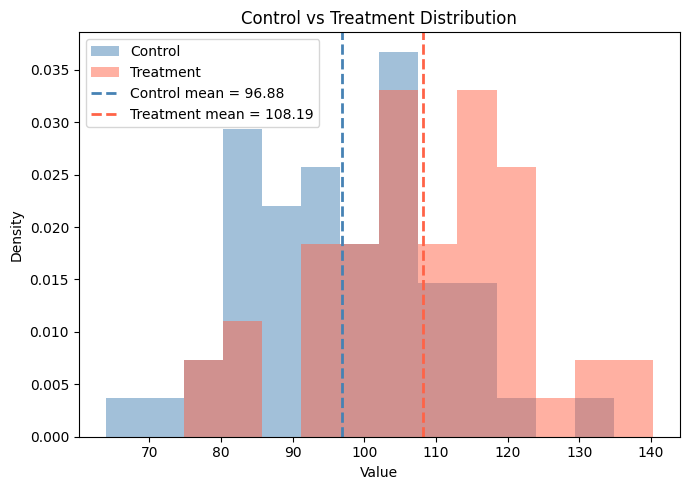

Two-sample t-test summary


,Metric,Value
0,Control mean,96.881317
1,Treatment mean,108.185231
2,P-value,0.000092
3,Conclusion (α=0.05),Reject H0 (significant difference)


In [4]:
# Two treatment groups
control = Normal(100,15).GenerateRandomValues(50,456)
treatment = Normal(110,15).GenerateRandomValues(50,789)
control_py = np.asarray(control)
treatment_py = np.asarray(treatment)

# Graph treatment groups
plt.figure(figsize=(7, 5))

bins = np.linspace(min(control_py.min(), treatment_py.min()),
                   max(control_py.max(), treatment_py.max()), 15)

plt.hist(control_py, bins=bins, alpha=0.5, density=True, color="steelblue", label="Control")
plt.hist(treatment_py, bins=bins, alpha=0.5, density=True, color="tomato", label="Treatment")
# Graph means
plt.axvline(control_py.mean(), color="steelblue", linestyle="--", linewidth=2,
            label=f"Control mean = {control_py.mean():.2f}")
plt.axvline(treatment_py.mean(), color="tomato", linestyle="--", linewidth=2,
            label=f"Treatment mean = {treatment_py.mean():.2f}")

plt.title("Control vs Treatment Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Conduct an equal variance test
pval = HypothesisTests.EqualVarianceTtest(control, treatment)
conclusion = 'Reject H0 (significant difference)' if pval < 0.05 else 'Fail to reject H0'

ttest_df = pd.DataFrame({'Metric':['Control mean','Treatment mean','P-value','Conclusion (α=0.05)'],'Value':
                         [np.mean(control_py),np.mean(treatment_py),pval,conclusion]})
print('Two-sample t-test summary')
display(ttest_df)

## Hypothesis Testing: (Non-Parametric) Mann-Whitney U
Non-parametric alternative to two-sample t-test (tests if distributions differ).
It ranks all observations and tests whether one sample tends to have larger ranks than the other. It is robust to non-normality but assumes independent samples and (for a median-shift interpretation) similar distribution shapes.

Hypotheses:
- H₀: Distributions are equal
- H₁: Distributions differ


Mann-Whitney U test summary


,Metric,Value
0,Group A median,16.030177
1,Group B median,13.024141
2,P-value,0.355611
3,Conclusion (α=0.05),No significant distribution difference


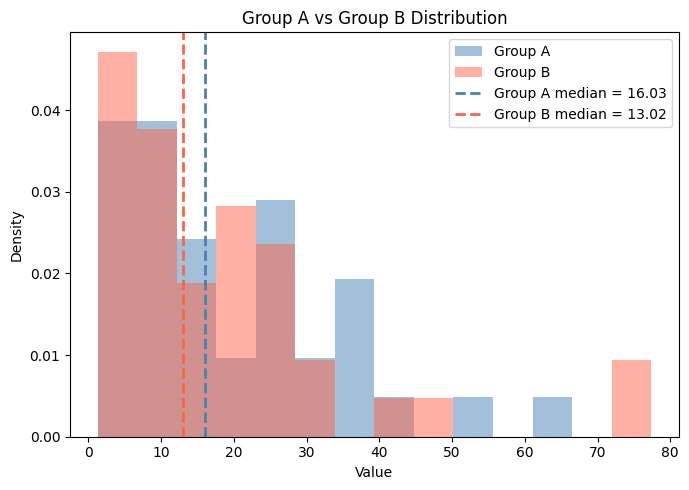

In [5]:
# Non-normal data (skewed)
group_a = Exponential(1, 25).GenerateRandomValues(40, 789)
group_b = Exponential(1, 20). GenerateRandomValues(40,789)

# Convert to Python lists for simplicity
group_a_py = np.array(group_a)
group_b_py = np.array(group_b)

pval = HypothesisTests.MannWhitneyTest(group_a, group_b)
conclusion = 'Significant distribution difference' if pval < 0.05 else 'No significant distribution difference'

mw_df = pd.DataFrame({'Metric':['Group A median','Group B median','P-value','Conclusion (α=0.05)'],'Value':
                      [np.median(group_a_py),np.median(group_b_py),pval,conclusion]})
print('Mann-Whitney U test summary')
display(mw_df)

# Graph treatment groups
plt.figure(figsize=(7, 5))

bins = np.linspace(min(group_a_py.min(), group_a_py.min()),
                   max(group_b_py.max(), group_b_py.max()), 15)

plt.hist(group_a_py, bins=bins, alpha=0.5, density=True, color="steelblue", label="Group A")
plt.hist(group_b_py, bins=bins, alpha=0.5, density=True, color="tomato", label="Group B")
# Graph means
plt.axvline(np.median(group_a_py), color="steelblue", linestyle="--", linewidth=2,
            label=f"Group A median = {np.median(group_a_py):.2f}")
plt.axvline(np.median(group_b_py), color="tomato", linestyle="--", linewidth=2,
            label=f"Group B median = {np.median(group_b_py):.2f}")

plt.title("Group A vs Group B Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Goodness-of-Fit: Kolmogorov-Smirnov Test
The Kolmogorov-Smirnov (K-S) test statistic measures the maximum vertical distance between the empirical cumulative distribution function (ECDF) and the theoretical CDF:

$$
D_n = \sup_x |F_n(x) - F(x)|
$$

where $F_n(x)$ is the empirical CDF defined as the proportion of observations less than or equal to $x$:

$$
F_n(x) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}_{[x_i \leq x]}
$$

and $F(x)$ is the CDF of the hypothesized distribution.

Limitations:
- Most sensitive near the center (median) of the distribution, less sensitive in the tails
- Critical values depend on whether parameters are estimated from data; when parameters are estimated, the Lilliefors correction is needed for valid p-values
- Conservative when used with estimated parameters (rejects too infrequently)
- Power decreases for heavy-tailed distributions
- The Anderson-Darling test is generally preferred when tail behavior is important [[6]](#6)

Overall, it tests if data comes from a specified distribution.

In [6]:
# Numerics does not currently provide a direct method for KS p-value calculation, so we implement it here based on the asymptotic formula.
# The test statistic is compared to the Kolmogrov distribution
def ks_pvalue_one_sample(d, n, tol=1e-8, k_max=1000):
    """
    Two-sided one-sample KS p-value for statistic d and sample size n.
    """
    if n <= 0:
        raise ValueError("n must be positive")

    # Transformation for better approximation
    lam = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * d

    # Series expansion
    s = 0.0
    for k in range(1, k_max+1):
        term = (-1)**(k-1) * np.exp(-2 * (k**2) * (lam**2))
        s += term
        if abs(term) < tol:
            break
    p = 2 * s
    # Numerical safety
    p = min(max(p, 0.0), 1.0)
    return p

Kolmogorov-Smirnov goodness-of-fit summary

,Metric,Value
0,Sample mean,51.544355
1,Sample std,76.611037
2,KS statistic,0.393603
3,P-value,0.0
4,Conclusion (α=0.05),"Data inconsistent with Normal(50,10)"


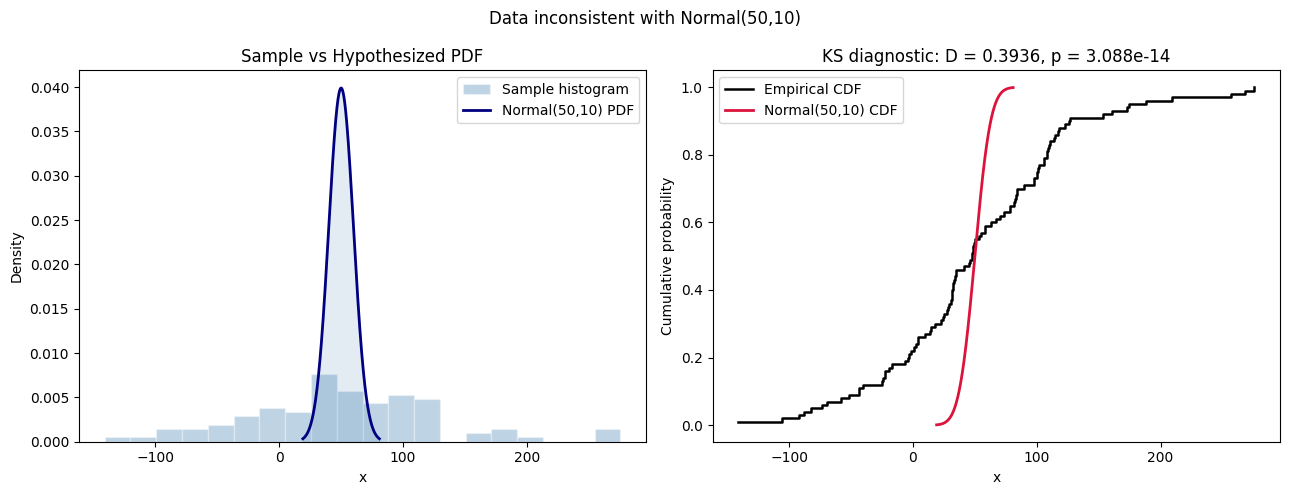

In [7]:
# Generate data
sample_data = Normal(50,100).GenerateRandomValues(100, 123)
sample_py = np.array(sample_data)
sample_py_sorted = np.sort(sample_py)
sample_data_sorted = convert_to_dotnet_array(sample_py_sorted)

hypothesized_dist = Normal(50, 10)
# This returns the KS test statistic - smaller D indicates a better fit
ks_test = GoodnessOfFit.KolmogorovSmirnov(sample_data_sorted, hypothesized_dist) # Needs sorted data
pval = ks_pvalue_one_sample(ks_test, len(sample_py))
conclusion = 'Data inconsistent with Normal(50,10)' if pval < 0.05 else 'Data consistent with Normal(50,10)'

ks_df = pd.DataFrame({'Metric':['Sample mean','Sample std','KS statistic','P-value','Conclusion (α=0.05)'],'Value':
                      [np.mean(sample_py),np.std(sample_py, ddof=1),ks_test,pval,conclusion]})
print('Kolmogorov-Smirnov goodness-of-fit summary')
display(ks_df)

# Range for smooth theoretical curve
x_min = hypothesized_dist.InverseCDF(0.001)
x_max = hypothesized_dist.InverseCDF(0.999)
x = np.linspace(x_min, x_max, 500)
pdf = np.array([hypothesized_dist.PDF(xi) for xi in x])
cdf = np.array([hypothesized_dist.CDF(xi) for xi in x])

# Empirical CDF (for KS visualization)
x_ecdf = np.sort(sample_py)
y_ecdf = np.arange(1, len(x_ecdf) + 1) / len(x_ecdf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram + theoretical PDF
ax1.hist(sample_py, bins=20, density=True, alpha=0.35, color="steelblue", edgecolor="white", label="Sample histogram")
ax1.plot(x, pdf, color="navy", linewidth=2, label="Normal(50,10) PDF")
ax1.fill_between(x, pdf, alpha=0.15, color="steelblue")
ax1.set_title("Sample vs Hypothesized PDF")
ax1.set_xlabel("x")
ax1.set_ylabel("Density")
ax1.legend()

# ECDF + theoretical CDF
ax2.step(x_ecdf, y_ecdf, where="post", color="black", linewidth=1.8, label="Empirical CDF")
ax2.plot(x, cdf, color="crimson", linewidth=2, label="Normal(50,10) CDF")
ax2.set_title(f"KS diagnostic: D = {ks_test:.4f}, p = {pval:.4g}")
ax2.set_xlabel("x")
ax2.set_ylabel("Cumulative probability")
ax2.legend()

fig.suptitle(conclusion)
fig.tight_layout()
plt.show()

## Bootstrap Resampling

To estimate sampling distribution without parametric assumptions, we can use Numerics BootstrapAnalysis method. Bootstrap resampling repeatedly draws samples (with replacement) from the observed data, computes the statistic of interest each time, and uses the resulting distribution to estimate standard errors and confidence intervals. The key choices are the number of resamples and the statistic being bootstrapped.

Bootstrap summary (5000 replicates)


,Statistic,Sample Estimate,Bootstrap Mean,95% CI Lower,95% CI Upper
0,Mean,38.029598,38.008305,35.884172,40.192871
1,Std Dev,7.705654,7.679659,6.142332,9.363730


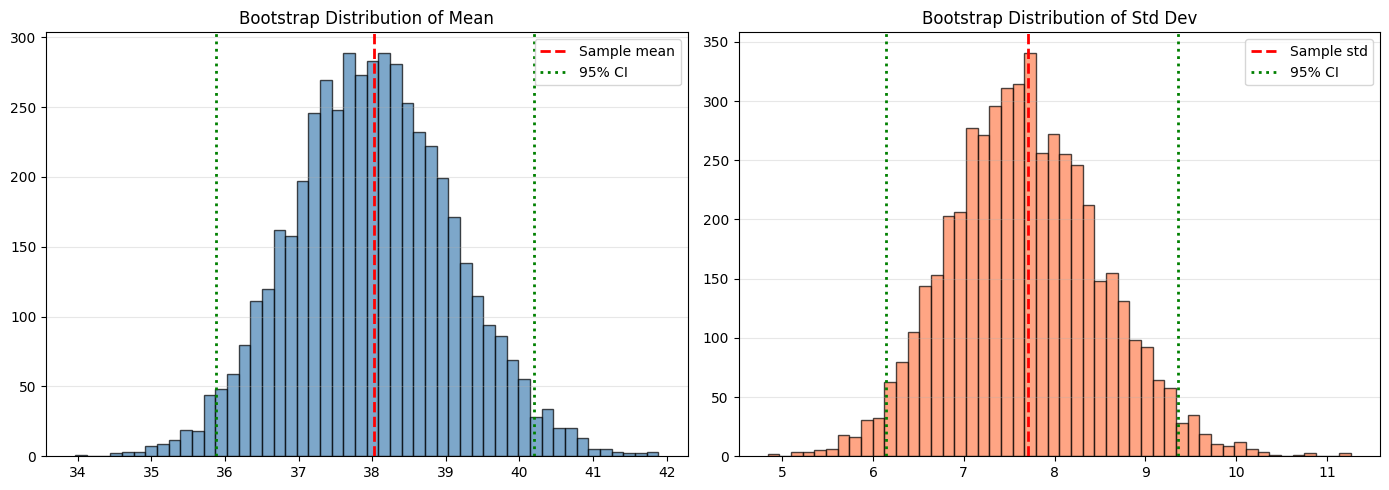

In [8]:
# Reproducible sample (same as your original setup)
original_sample = GammaDistribution(2,20).GenerateRandomValues(50, 456)

# Fit parent distribution to original sample
parent = GammaDistribution()
parent.Estimate(original_sample, ParameterEstimationMethod.MethodOfMoments)

# Configure Numerics bootstrap
n_boot = 5000
bootstrap = BootstrapAnalysis(
    distribution=parent,    # Source model for bootstrap
    estimationMethod=ParameterEstimationMethod.MethodOfMoments, # For each bootstrap sample, params are re-estimated using MOM
    sampleSize=len(original_sample),
    replications=n_boot,
    seed=456
)

# Bootstrap product moments: columns = [mean, std, skew, kurt]
boot_moments = bootstrap.ProductMoments()
boot_means = np.array([boot_moments[i, 0] for i in range(n_boot)], dtype=float)
boot_means_net = convert_to_dotnet_array(boot_means.tolist())
boot_stds = np.array([boot_moments[i, 1] for i in range(n_boot)], dtype=float)
boot_stds_net = convert_to_dotnet_array(boot_stds.tolist())

# 95% percentile CIs
ci_mean = Statistics.Percentile(boot_means_net, Array[float]([0.025, 0.975]))
ci_std = Statistics.Percentile(boot_stds_net, Array[float]([0.025, 0.975]))

boot_df = pd.DataFrame([
    {
        'Statistic': 'Mean',
        'Sample Estimate': float(np.mean(original_sample)),
        'Bootstrap Mean': float(np.mean(boot_means)),
        '95% CI Lower': float(ci_mean[0]),
        '95% CI Upper': float(ci_mean[1])
    },
    {
        'Statistic': 'Std Dev',
        'Sample Estimate': float(np.std(original_sample, ddof=1)),
        'Bootstrap Mean': float(np.mean(boot_stds)),
        '95% CI Lower': float(ci_std[0]),
        '95% CI Upper': float(ci_std[1])
    },
])

print(f'Bootstrap summary ({n_boot} replicates)')
display(boot_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bootstrap of the mean
axes[0].hist(boot_means, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(original_sample), color='red', linestyle='--', linewidth=2, label='Sample mean')
axes[0].axvline(ci_mean[0], color='green', linestyle=':', linewidth=2, label='95% CI')
axes[0].axvline(ci_mean[1], color='green', linestyle=':', linewidth=2)
axes[0].set_title('Bootstrap Distribution of Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Bootstrap of the std
axes[1].hist(boot_stds, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.std(original_sample, ddof=1), color='red', linestyle='--', linewidth=2, label='Sample std')
axes[1].axvline(ci_std[0], color='green', linestyle=':', linewidth=2, label='95% CI')
axes[1].axvline(ci_std[1], color='green', linestyle=':', linewidth=2)
axes[1].set_title('Bootstrap Distribution of Std Dev')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Outlier Detection: Multiple Grubbs-Beck Test
### Grubbs-Beck Test

The original Grubbs-Beck test [[7]](#7) identifies high and low outlier thresholds at the 10% significance level. The test assumes the log-transformed data follow a normal distribution and uses a critical value $K_n$ based on sample size:

$$
X_{Hi} = \exp(\bar{y} + K_n \cdot s_y), \quad X_{Lo} = \exp(\bar{y} - K_n \cdot s_y)
$$

where $\bar{y}$ and $s_y$ are the mean and standard deviation of the log-transformed sample.

### Multiple Grubbs-Beck Test

The Multiple Grubbs-Beck Test [[8]](#8) is a generalization that can detect multiple potentially influential low flows (PILFs). This is particularly important in Bulletin 17C flood frequency analysis, where low outliers can distort the fitted distribution and bias upper-tail quantile estimates.

**Guidance:** Use the original Grubbs-Beck test for general-purpose outlier screening. Use the Multiple Grubbs-Beck test specifically for Bulletin 17C flood frequency analysis where multiple low outliers may influence the Log-Pearson Type III fit.



Multiple Grubbs-Beck summary


,Metric,Value
0,Sample size,50.000000
1,Mean,98.159548
2,Std Dev,21.844798
3,Low outliers detected (MGBT),2.000000


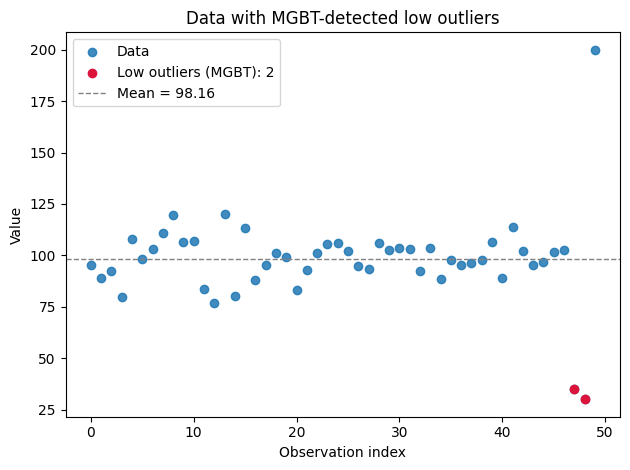

In [9]:
# Data with outliers
clean_data = np.asarray(Normal(100,10).GenerateRandomValues(47,789))
#np.random.normal(100, 10, 47)
outliers_vals = np.array([35, 30, 200])
data_with_outliers = np.concatenate([clean_data, outliers_vals])
data_net = convert_to_dotnet_array(data_with_outliers)

mean_val = Statistics.Mean(data_net)
std_val = Statistics.StandardDeviation(data_net)
grubbs = MultipleGrubbsBeckTest.Function(data_net)

outlier_df = pd.DataFrame({'Metric':['Sample size','Mean','Std Dev','Low outliers detected (MGBT)'],'Value':
                           [len(data_with_outliers),mean_val,std_val,grubbs]})
print('Multiple Grubbs-Beck summary')
display(outlier_df)


# Identify which points are low outliers for plotting
sorted_idx = np.argsort(data_with_outliers)
low_outlier_idx = sorted_idx[:grubbs] if grubbs > 0 else np.array([], dtype=int)

# Plot data with identified low outliers
x = np.arange(len(data_with_outliers))
plt.scatter(x, data_with_outliers, alpha=0.85, label="Data")
if grubbs > 0:
    plt.scatter(low_outlier_idx, data_with_outliers[low_outlier_idx], color="crimson",
                label=f"Low outliers (MGBT): {grubbs}")
plt.axhline(mean_val, color="gray", linestyle="--", linewidth=1, label=f"Mean = {mean_val:.2f}")
plt.title("Data with MGBT-detected low outliers")
plt.xlabel("Observation index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Jenks Natural Breaks
Optimal classification for univariate data. The Jenks Natural Breaks algorithm (also known as the Fisher-Jenks algorithm) partitions a sorted univariate dataset into $k$ classes by minimizing the within-class sum of squared deviations while maximizing the between-class separation. The quality of a classification is measured by the Goodness of Variance Fit (GVF):

$$
\text{GVF} = \frac{\text{SDAM} - \text{SDCM}}{\text{SDAM}}
$$

where SDAM is the sum of squared deviations from the array (overall) mean:

$$
\text{SDAM} = \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

and SDCM is the sum of squared deviations from the class means:

$$
\text{SDCM} = \sum_{c=1}^{k} \sum_{x \in C_c} (x - \bar{x}_c)^2
$$

A GVF of 1.0 indicates a perfect fit (zero within-class variance), while values closer to 0 indicate poor classification. The algorithm uses dynamic programming to efficiently find the optimal break points that maximize the GVF, avoiding the exponential cost of exhaustive search over all possible partitions.


Jenks Natural Breaks summary


,Metric,Value
0,Classes (k),5
1,Goodness of Variance Fit (GVF),0.9632
2,Breaks,"[35.0, 89.10187406055996, 103.59864269665528, ..."


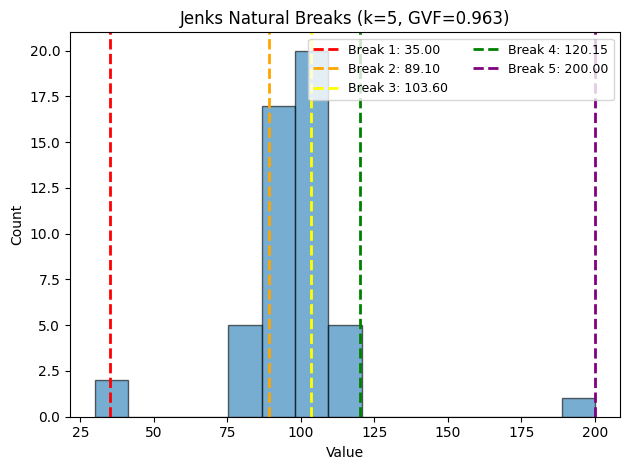

In [10]:
# Reuse data_with_outliers from the Grubbs-Beck section
data_net = convert_to_dotnet_array(data_with_outliers)

k = 5
jenks = JenksNaturalBreaks(data_net, k)
breaks = list(jenks.Breaks)
gvf = jenks.GoodnessOfVarianceFit

jenks_df = pd.DataFrame({'Metric':['Classes (k)','Goodness of Variance Fit (GVF)','Breaks'],'Value':[k, gvf, breaks]})
print('Jenks Natural Breaks summary')
display(jenks_df)


# Histogram + Jenks break lines 
colors = ['red','orange','yellow','green','purple']
plt.hist(data_with_outliers, bins="auto", alpha=0.6, edgecolor="black")
for i, b in enumerate(breaks):
    plt.axvline(b, linestyle="--", linewidth=2, label=f"Break {i+1}: {b:.2f}", color = colors[i])
plt.title(f"Jenks Natural Breaks (k={k}, GVF={gvf:.3f})")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 8. Data Transformations

The Box Cox and Yeo-Johnson transformations transform non-normal dependent variables into a normal shape. Box-Cox requires strictly positive data and finds a power, $\lambda$, that stabilizes variance and reduces skew. Yeo-Johnson is similar but allows zero and negative values, making it safer for general datasets. Both are often used before regression or hypothesis tests that assume normality.


Transformation summary table


,Transform,Sample Size,Mean,Std,Min,Max,Lambda,Round-Trip Error
0,Box-Cox (original),500,38.944335,132.921321,0.077764,1942.229448,0.020475,2.273737e-12
1,Box-Cox (transformed),500,2.380719,1.721469,-2.488445,8.190029,0.020475,2.273737e-12
2,Yeo-Johnson (original),500,2.527081,3.536851,-4.984451,18.998849,0.709817,3.552714e-15
3,Yeo-Johnson (transformed),500,1.645339,2.560638,-7.020563,10.403343,0.709817,3.552714e-15


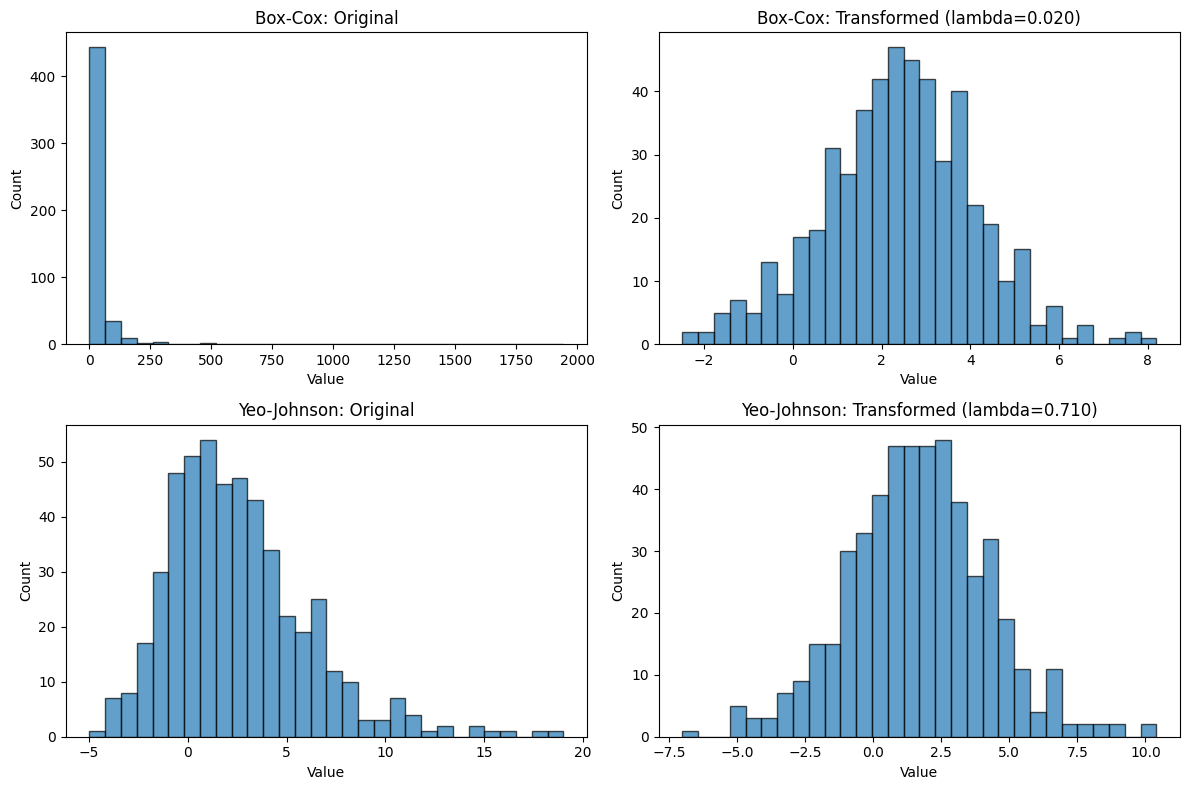

In [11]:
boxcox_data = LogNormal(1,0.75).GenerateRandomValues(500, 789) 
lambda_bc = BoxCox.FitLambda(boxcox_data)
bc_transformed = BoxCox.Transform(boxcox_data, lambda_bc)
bc_inverse = BoxCox.InverseTransform(bc_transformed, lambda_bc)
bc_error = np.max(np.abs(np.asarray(boxcox_data) - np.asarray(list(bc_inverse))))

yeojohnson_data =  np.array(Normal(0,2).GenerateRandomValues(500,456)) + np.array(Exponential(1, 1.5).GenerateRandomValues(500, 456))
yeojohnson_data_net = convert_to_dotnet_array(yeojohnson_data)
lambda_yj = YeoJohnson.FitLambda(yeojohnson_data_net)
yj_transformed = YeoJohnson.Transform(yeojohnson_data_net, lambda_yj)
yj_inverse = YeoJohnson.InverseTransform(yj_transformed, lambda_yj)
yj_error = np.max(np.abs(np.asarray(yeojohnson_data) - np.asarray(list(yj_inverse))))

transform_df = pd.DataFrame([
    {'Transform':'Box-Cox (original)','Sample Size':len(boxcox_data),'Mean':np.mean(boxcox_data),'Std':np.std(boxcox_data),'Min':np.min(boxcox_data),'Max':np.max(boxcox_data),'Lambda':lambda_bc,'Round-Trip Error':bc_error},
    {'Transform':'Box-Cox (transformed)','Sample Size':len(bc_transformed),'Mean':np.mean(bc_transformed),'Std':np.std(bc_transformed),'Min':np.min(bc_transformed),'Max':np.max(bc_transformed),'Lambda':lambda_bc,'Round-Trip Error':bc_error},
    {'Transform':'Yeo-Johnson (original)','Sample Size':len(yeojohnson_data),'Mean':np.mean(yeojohnson_data),'Std':np.std(yeojohnson_data),'Min':np.min(yeojohnson_data),'Max':np.max(yeojohnson_data),'Lambda':lambda_yj,'Round-Trip Error':yj_error},
    {'Transform':'Yeo-Johnson (transformed)','Sample Size':len(yj_transformed),'Mean':np.mean(yj_transformed),'Std':np.std(yj_transformed),'Min':np.min(yj_transformed),'Max':np.max(yj_transformed),'Lambda':lambda_yj,'Round-Trip Error':yj_error},
])
print('Transformation summary table')
display(transform_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Box-Cox hist
axes[0,0].hist(boxcox_data, bins=30, alpha=0.7, edgecolor='black')
axes[0,0].set_title("Box-Cox: Original")
axes[0,0].set_xlabel("Value"); axes[0,0].set_ylabel("Count")

axes[0,1].hist(bc_transformed, bins=30, alpha=0.7, edgecolor='black')
axes[0,1].set_title(f"Box-Cox: Transformed (lambda={lambda_bc:.3f})")
axes[0,1].set_xlabel("Value"); axes[0,1].set_ylabel("Count")

# Yeo-Johnson hist
axes[1,0].hist(yeojohnson_data, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_title("Yeo-Johnson: Original")
axes[1,0].set_xlabel("Value"); axes[1,0].set_ylabel("Count")

axes[1,1].hist(yj_transformed, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title(f"Yeo-Johnson: Transformed (lambda={lambda_yj:.3f})")
axes[1,1].set_xlabel("Value"); axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Key Takeaways

1. Start with visualization → Always plot your data first
2. Check assumptions → Use Q-Q plots and normality tests
3. Choose appropriate tests → Parametric vs non-parametric
4. Bootstrap for uncertainty → Works without strong assumptions
5. Handle outliers carefully → Investigate before removing

## Statistical Test Selection Guide

| Situation | Test to Use |
|-----------|-------------|
| Compare 2 means (normal data) | t-test |
| Compare 2 means (non-normal) | Mann-Whitney U |
| Test for normality | KS test, Q-Q plot |
| Outlier detection | Grubbs' test |
| Confidence intervals | Bootstrap |
| Normalize skewed data | Box-Cox transform |
| Mixed signs data | Yeo-Johnson transform |

## Summary

You've learned:

$\checkmark$ Descriptive statistics and data exploration  
$\checkmark$ Correlation analysis (Pearson, Spearman, Kendall)     
$\checkmark$ Parametric testing (t-test)       
$\checkmark$ Non-parametric testing (Mann-Whitney)     
$\checkmark$ Goodness-of-fit testing (KS test)     
$\checkmark$ Bootstrap confidence intervals        
$\checkmark$ Outlier detection (Grubbs' test)      
$\checkmark$ Data transformations (Box-Cox, Yeo-Johnson) 

## Exercise

1. Generate two samples from different distributions
2. Perform both t-test and Mann-Whitney test
3. Create bootstrap confidence intervals
4. Which test is more appropriate? Why?


## References

<a id="1">[1]</a> B. P. Welford, "Note on a method for calculating corrected sums of squares and products," *Technometrics*, vol. 4, no. 3, pp. 419-420, 1962.

<a id="2">[2]</a> R. A. Fisher, "The moments of the distribution for normal samples of measures of departure from normality," *Proceedings of the Royal Society of London. Series A*, vol. 130, no. 812, pp. 16-28, 1930.

<a id="3">[3]</a> A. M. Mood, F. A. Graybill, and D. C. Boes, *Introduction to the Theory of Statistics*, 3rd ed. McGraw-Hill, 1974.

<a id="4">[4]</a> M. G. Kendall, "A new measure of rank correlation," *Biometrika*, vol. 30, no. 1-2, pp. 81-93, 1938.

<a id="5">[5]</a> G. Casella and R. L. Berger, *Statistical Inference*, 2nd ed. Duxbury/Thomson, 2002.

<a id="6">[6]</a> T. W. Anderson and D. A. Darling, "A test of goodness of fit," *Journal of the American Statistical Association*, vol. 49, no. 268, pp. 765-769, 1954.

<a id="7">[7]</a> F. E. Grubbs and G. Beck, "Extension of sample sizes and percentage points for significance tests of outlying observations," *Technometrics*, vol. 14, no. 4, pp. 847-854, 1972.

<a id="8">[8]</a> England, J. F., Cohn, T. A., Faber, B. A., Stedinger, J. R., Thomas, W. O., Veilleux, A. G., Kiang, J. E., & Mason, R. R. (2019). *Guidelines for Determining Flood Flow Frequency — Bulletin 17C* (Techniques and Methods 4–B5). U.S. Geological Survey. https://doi.org/10.3133/tm4B5